# Dataset Loading 
Load your self-generated digits dataset from `dataset/labels.csv` and `dataset/images/*`.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()  # coursework.ipynb is in /project
LABELS_CSV = PROJECT_DIR / 'dataset' / 'labels.csv'

df = pd.read_csv(LABELS_CSV)
df.head()

cur dir :  /Users/raheemkhan/Documents/3rd-Year/Principles_of_AI/project
labels address :  /Users/raheemkhan/Documents/3rd-Year/Principles_of_AI/project/dataset/labels.csv
Rows in labels.csv: 1200


,filepath,label,writer_id,sheet_id,source_sheet,cell_index
0,dataset/images/0/ Khan_ 0_ sheet1_ 0.png,0,Khan,sheet1,Khan_0_sheet1.JPG,0
1,dataset/images/0/ Khan_ 0_ sheet1_ 1.png,0,Khan,sheet1,Khan_0_sheet1.JPG,1
2,dataset/images/0/ Khan_ 0_ sheet1_ 2.png,0,Khan,sheet1,Khan_0_sheet1.JPG,2
3,dataset/images/0/ Khan_ 0_ sheet1_ 3.png,0,Khan,sheet1,Khan_0_sheet1.JPG,3
4,dataset/images/0/ Khan_ 0_ sheet1_ 4.png,0,Khan,sheet1,Khan_0_sheet1.JPG,4


In [48]:
# Loading the dataset and listing the size and images per class
X_list ,y_list = [],[]
for row in df.itertuples(index=False):
    img_path = row.filepath
    img = Image.open(img_path).convert("L").resize((28,28))
    X_list.append(np.array(img,dtype=np.uint8))
    y_list.append(int(row.label))

X = np.stack(X_list)
y = np.array(y_list, dtype=np.int64)

print("Total dataset size: ", len(X))

unique, count = np.unique(y, return_counts=True)
print("Images per class:")
for u, c in zip(unique, count):
    print(f"Digit {u} : {c}")

Total dataset size:  1200
Images per class:
Digit 0 : 200
Digit 1 : 200
Digit 2 : 200
Digit 3 : 200
Digit 4 : 200
Digit 5 : 200


# Normalising the pixel values
To improve the numerical stability and ensuring consisten feature scaling.

In [37]:
# Normalising the pixel values
X_float = X.astype(np.float32) / 255.0
X_flat = X_float.reshape(len(X_float), -1)  # (N, 784)

print(X_float.dtype)



float32


# Data Split 
The Data split will be 80/20

The random seed is set to 42

In [40]:
# using sklean to split the train dataset
from sklearn.model_selection import train_test_split
import random

SEED = 42 # taking the usual number

random.seed(SEED)
np.random.seed(SEED)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
    shuffle=True
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Random seed:", SEED)

Train size: 960
Test size: 240
Random seed: 42


# Traning Model

In [ ]:
# importing Logistic regression model and training it
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(
    # multi_class="multinomial",  getting warning that multiclass is deprecated and the default is multinomial so going to remove this for now
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)
clf.fit(X_train, y_train)

/Users/raheemkhan/anaconda3/envs/compvis/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


# Predictions and Results and Evaluations

In [32]:
y_pred = clf.predict(X_test)
probs = clf.predict_proba(X_test) # shape: (num_samples, num_classes)

In [34]:
from sklearn.metrics import accuracy_score, classification_report, log_loss
acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, probs)
print(f"Test accuracy: {acc:.4f}")

print(f"Log Loss : {loss:.4f}")
print(classification_report(y_test, y_pred))


Test accuracy: 0.6583
Log Loss : 0.9883
              precision    recall  f1-score   support

           0       0.53      0.50      0.51        40
           1       0.69      0.85      0.76        40
           2       0.97      0.97      0.97        40
           3       0.62      0.72      0.67        40
           4       0.47      0.45      0.46        40
           5       0.64      0.45      0.53        40

    accuracy                           0.66       240
   macro avg       0.65      0.66      0.65       240
weighted avg       0.65      0.66      0.65       240



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2,3,4,5])
cm_display= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4,5])
print(cm)

[[20  7  0  3  9  1]
 [ 0 34  0  4  2  0]
 [ 0  1 39  0  0  0]
 [ 0  3  0 29  3  5]
 [10  3  1  4 18  4]
 [ 8  1  0  7  6 18]]


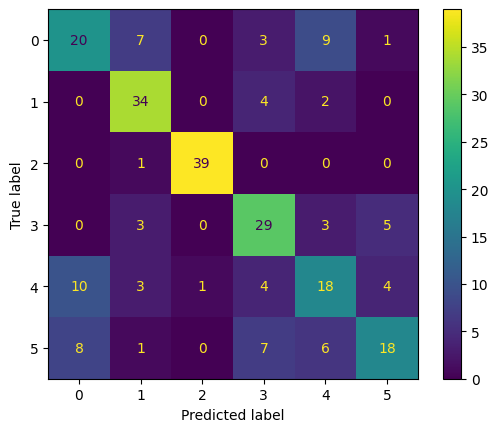

In [ ]:
# plotting the confusion matrix
import matplotlib.pyplot as plt
cm_display.plot()
plt.show()